In [1]:
"""
Data exploration

Pure exploration of the already-cleaned ES 1-min bars in data/processed/
(see data_cleaning.py, which owns raw -> processed) — summary statistics,
anomaly scans (gaps, bad OHLC, price/volume spikes), and DTW prototyping.
This notebook only reads data/processed/; it never writes to it.
"""

import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dtaidistance import dtw

DATA_DIR = Path("../data")
PROCESSED_FILE = DATA_DIR / "processed" / "es_1min_bars_2010_2026.parquet"

pd.set_option("display.width", 120)

## Load processed data

Assumes `data_cleaning.py` has already been run to produce this file.

In [2]:
df = pd.read_parquet(PROCESSED_FILE)
df.head()

,open,high,low,close,volume
timestamp,,,,,
2010-07-01 00:00:00+00:00,1026.25,1026.25,1026.00,1026.00,225
2010-07-01 00:01:00+00:00,1026.25,1026.25,1026.00,1026.25,90
2010-07-01 00:02:00+00:00,1026.25,1026.25,1026.00,1026.25,86
2010-07-01 00:03:00+00:00,1026.00,1026.50,1026.00,1026.50,111
2010-07-01 00:04:00+00:00,1026.25,1027.00,1026.25,1027.00,781


## Summary statistics

In [3]:
print("shape:", df.shape)
print("date range:", df.index.min(), "->", df.index.max())
print("duplicated timestamps:", df.index.duplicated().sum())
print("nulls per column:\n", df.isna().sum())

shape: (4811336, 5)
date range: 2010-07-01 00:00:00+00:00 -> 2026-06-30 23:59:00+00:00
duplicated timestamps: 0
nulls per column:
 open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [4]:
df.describe()

,open,high,low,close,volume
count,4.811336e+06,4.811336e+06,4.811336e+06,4.811336e+06,4.811336e+06
mean,3.409067e+03,3.409585e+03,3.408545e+03,3.409067e+03,1.249397e+03
std,1.590461e+03,1.590669e+03,1.590248e+03,1.590461e+03,2.140194e+04
min,1.004000e+03,1.004250e+03,1.002750e+03,1.003750e+03,1.000000e+00
25%,2.088500e+03,2.088750e+03,2.088250e+03,2.088500e+03,7.300000e+01
50%,2.913500e+03,2.914000e+03,2.913250e+03,2.913500e+03,2.310000e+02
75%,4.404000e+03,4.404750e+03,4.403250e+03,4.404000e+03,1.076000e+03
max,7.631500e+03,7.632250e+03,7.630750e+03,7.631500e+03,6.223210e+06


In [5]:
df.groupby(df.index.year).agg(
    rows=("close", "size"),
    avg_close=("close", "mean"),
    avg_volume=("volume", "mean"),
)

,rows,avg_close,avg_volume
timestamp,,,
2010,51942,1142.939259,4302.843133
2011,120683,1271.004580,4367.843126
2012,157576,1392.304655,2557.355397
2013,265734,1640.146780,1434.679563
2014,261479,1926.292164,1329.283587
2015,295041,2055.878352,1228.960775
2016,345992,2087.560061,1144.540134
2017,341043,2444.607816,878.453790
2018,346451,2748.329678,1056.926324


**Findings:** 2010-07-01 through 2026-06-30, no nulls or duplicate timestamps.
Volume is heavily skewed (mean ~1,249/min, std ~21,400, max 6.2M) and, oddly,
*declines* by year — avg volume/min drops from ~4,300 (2010-2012) to
~950-1,200 (2023-2026) even as price levels rise 6-7x. That's backwards for a
market that's grown, and worth checking against the roll/continuous-contract
methodology or a vendor aggregation change.

## Anomaly scan: time gaps

ES trades nearly 24h/day (CME Globex) with a ~1hr daily maintenance break
and weekend closures, so gaps aren't inherently bad — but unusually large
gaps outside that pattern are worth a look.

In [6]:
deltas = df.index.to_series().diff().dropna()
gap_counts = deltas.value_counts().sort_index(ascending=False)
gap_counts.head(15)

timestamp
3 days 22:01:00     1
3 days 12:35:00     2
3 days 11:26:00     1
3 days 04:46:00     2
3 days 01:01:00    19
3 days 00:32:00     1
3 days 00:31:00     1
3 days 00:30:00     1
3 days 00:26:00     1
3 days 00:25:00     4
2 days 23:58:00     1
2 days 22:49:00     1
2 days 08:46:00     3
2 days 08:45:00     1
2 days 08:31:00    51
Name: count, dtype: int64

In [7]:
LARGE_GAP = pd.Timedelta(hours=2)
large_gaps = deltas[deltas > LARGE_GAP].sort_values(ascending=False)
print(f"{len(large_gaps)} gaps > {LARGE_GAP}")
large_gaps.head(20)

1508 gaps > 0 days 02:00:00


timestamp
2014-06-15 22:00:00+00:00   3 days 22:01:00
2011-12-27 11:00:00+00:00   3 days 12:35:00
2012-01-03 11:00:00+00:00   3 days 12:35:00
2014-09-26 11:22:00+00:00   3 days 11:26:00
2015-12-27 23:00:00+00:00   3 days 04:46:00
2020-12-27 23:00:00+00:00   3 days 04:46:00
2018-01-01 23:00:00+00:00   3 days 01:01:00
2016-01-03 23:00:00+00:00   3 days 01:01:00
2019-04-21 22:00:00+00:00   3 days 01:01:00
2022-12-26 23:00:00+00:00   3 days 01:01:00
2023-01-02 23:00:00+00:00   3 days 01:01:00
2016-03-27 22:00:00+00:00   3 days 01:01:00
2018-04-01 22:00:00+00:00   3 days 01:01:00
2021-01-03 23:00:00+00:00   3 days 01:01:00
2017-12-25 23:00:00+00:00   3 days 01:01:00
2022-04-17 22:00:00+00:00   3 days 01:01:00
2024-01-01 23:00:00+00:00   3 days 01:01:00
2024-03-31 22:00:00+00:00   3 days 01:01:00
2017-04-16 22:00:00+00:00   3 days 01:01:00
2017-01-02 23:00:00+00:00   3 days 01:01:00
Name: timestamp, dtype: timedelta64[ns]

**Findings:** 1,508 gaps over 2 hours, topping out around 3d22h. All are
consistent with weekends/holidays (e.g. Christmas, New Year's long weekends)
— nothing unexplained beyond normal market closures.

## Anomaly scan: OHLC consistency

In [8]:
bad_ohlc = df[
    (df["high"] < df["low"])
    | (df["high"] < df["open"])
    | (df["high"] < df["close"])
    | (df["low"] > df["open"])
    | (df["low"] > df["close"])
]
print(f"{len(bad_ohlc)} rows with inconsistent OHLC")
bad_ohlc.head(20)

0 rows with inconsistent OHLC


,open,high,low,close,volume
timestamp,,,,,


In [9]:
non_positive = df[(df[["open", "high", "low", "close"]] <= 0).any(axis=1)]
print(f"{len(non_positive)} rows with non-positive prices")
non_positive.head(20)

0 rows with non-positive prices


,open,high,low,close,volume
timestamp,,,,,


**Findings:** Zero rows with inconsistent OHLC and zero with non-positive
prices — the data is structurally clean on both counts.

## Anomaly scan: price and volume spikes

In [10]:
returns = df["close"].pct_change()
z = (returns - returns.mean()) / returns.std()
price_spikes = df.loc[z.abs().sort_values(ascending=False).head(20).index]
price_spikes = price_spikes.assign(ret=returns.loc[price_spikes.index], z=z.loc[price_spikes.index])
price_spikes.sort_values("z", key=lambda s: s.abs(), ascending=False)

,open,high,low,close,volume,ret,z
timestamp,,,,,,,
2020-03-22 22:00:00+00:00,2220.25,2223.00,2185.25,2191.00,13225,-0.103885,-314.698159
2011-08-09 22:00:00+00:00,1178.00,1178.00,1175.75,1176.75,1470,0.066621,201.812346
2020-03-16 13:45:00+00:00,2441.75,2442.75,2375.00,2375.00,10746,-0.055102,-166.921381
2020-06-21 22:00:00+00:00,3040.25,3046.00,3038.75,3043.00,5178,-0.047872,-145.019467
2011-08-04 22:00:00+00:00,1197.50,1199.50,1197.00,1198.50,1612,-0.047108,-142.703867
2011-11-30 23:00:00+00:00,1244.75,1245.00,1244.00,1244.00,1114,0.043187,130.822218
2011-08-10 22:00:00+00:00,1121.00,1122.00,1120.75,1121.50,1876,-0.043089,-130.528661
2011-08-18 22:00:00+00:00,1142.75,1143.25,1141.75,1142.00,913,-0.038113,-115.456700
2011-11-09 23:00:00+00:00,1226.50,1227.00,1226.00,1226.00,626,-0.036731,-111.270860


**Findings:** The largest 1-min moves line up with real events, not bad
data — e.g. -10.4% at 2020-03-22 22:00 UTC (COVID Sunday-reopen crash),
+6.7% at 2011-08-09 22:00 UTC (US credit downgrade weekend), -5.5% at
2020-03-16 (COVID circuit-breaker day). Most cluster right at the Sunday
22:00/23:00 UTC weekly reopen, where weekend news gets priced in on the
first bar back.

In [11]:
zero_volume = df[df["volume"] == 0]
print(f"{len(zero_volume)} bars with zero volume ({len(zero_volume) / len(df):.3%})")

vol_z = (df["volume"] - df["volume"].mean()) / df["volume"].std()
volume_spikes = df.loc[vol_z.sort_values(ascending=False).head(20).index]
volume_spikes.assign(vol_z=vol_z.loc[volume_spikes.index])

0 bars with zero volume (0.000%)


,open,high,low,close,volume,vol_z
timestamp,,,,,,
2011-08-09 23:59:00+00:00,1175.75,1178.75,1077.00,1178.75,6223210,290.719521
2011-08-05 21:33:00+00:00,1195.50,1219.00,1163.25,1197.50,6101317,285.024101
2011-08-04 23:59:00+00:00,1195.50,1264.25,1193.25,1196.50,5020660,234.530679
2011-08-10 23:59:00+00:00,1123.00,1177.50,1113.75,1122.75,4858001,226.930479
2011-09-22 23:59:00+00:00,1131.25,1159.00,1106.75,1128.50,4712564,220.134972
2014-10-15 23:59:00+00:00,1873.75,1879.00,1813.00,1847.00,4623332,215.965630
2011-08-11 23:59:00+00:00,1166.25,1184.00,1103.00,1166.50,4418225,206.382057
2011-10-04 23:59:00+00:00,1116.25,1119.75,1068.00,1115.25,4173190,194.932860
2011-08-18 23:59:00+00:00,1136.50,1188.25,1128.25,1144.00,3797713,177.388793


**Findings:** No zero-volume bars. But most of the top-20 volume spikes
fall exactly at `23:59:00` across unrelated dates (2011-08-09, 2011-08-05,
2014-10-15, ...) — a repeating minute-of-day pattern like that suggests a
data artifact (session-boundary/settlement volume dumped into the last bar
of the UTC day) rather than organic trading, and is worth confirming with
databento/teammate before treating end-of-day volume as reliable.

## Quick visual: full close series with largest gaps/spikes marked

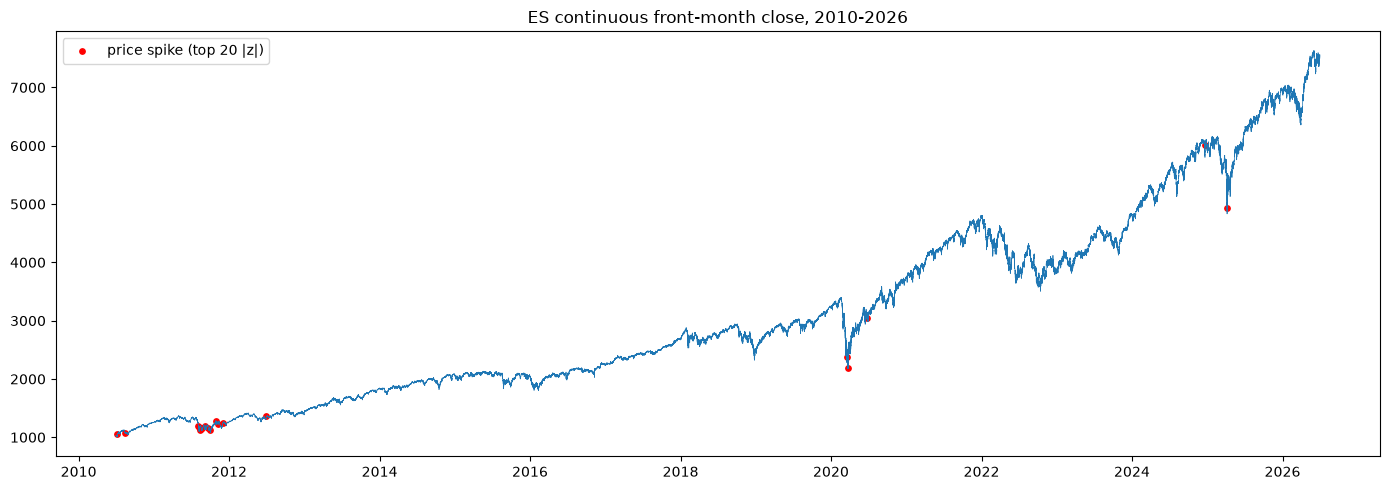

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["close"], linewidth=0.5)
ax.scatter(price_spikes.index, price_spikes["close"], color="red", s=15, label="price spike (top 20 |z|)")
ax.set_title("ES continuous front-month close, 2010-2026")
ax.legend()
fig.tight_layout()

## DTW exploration: picking a calm month

`dtaidistance`'s core distance function is C-compiled and fast per pair, but
a full pairwise similarity matrix is O(N^2) in the number of sequences — so
we start on a small, uneventful slice to get the API and cost right before
scaling up. We pick the calmest full month by realized 1-min volatility.

In [13]:
monthly_ret = df["close"].pct_change()
monthly_vol = monthly_ret.groupby(df.index.tz_convert(None).to_period("M")).std().dropna()
monthly_rows = df.groupby(df.index.tz_convert(None).to_period("M")).size()
full_months = monthly_rows[monthly_rows > monthly_rows.median() * 0.9].index
calmest = monthly_vol.loc[monthly_vol.index.intersection(full_months)].sort_values().head(10)
calmest

timestamp
2017-10    0.000110
2017-09    0.000124
2017-07    0.000126
2017-11    0.000128
2017-02    0.000134
2017-05    0.000136
2019-11    0.000142
2019-04    0.000144
2017-06    0.000144
2018-08    0.000146
Freq: M, Name: close, dtype: float64

rows: 29619
largest gaps:
 timestamp
2017-10-22 22:00:00+00:00   2 days 01:01:00
2017-10-15 22:00:00+00:00   2 days 01:01:00
2017-10-08 22:00:00+00:00   2 days 01:01:00
2017-10-29 22:00:00+00:00   2 days 01:01:00
2017-10-17 22:00:00+00:00   0 days 01:01:00
Name: timestamp, dtype: timedelta64[ns]
max abs 1-min return: 0.0016681385536257975


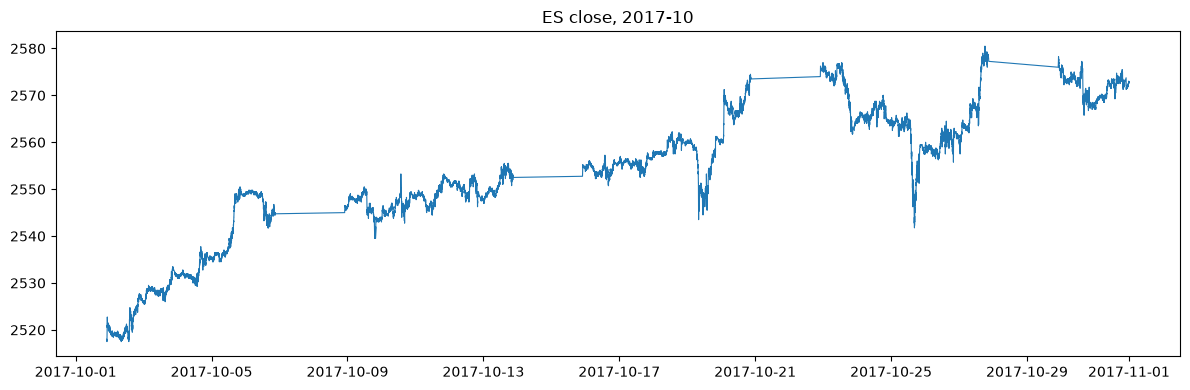

In [14]:
CALM_MONTH = "2017-10"
month = df.loc[CALM_MONTH]
gaps_in_month = month.index.to_series().diff().dropna().sort_values(ascending=False)
print("rows:", len(month))
print("largest gaps:\n", gaps_in_month.head(5))
print("max abs 1-min return:", monthly_ret.loc[month.index].abs().max())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(month.index, month["close"], linewidth=0.8)
ax.set_title(f"ES close, {CALM_MONTH}")
fig.tight_layout()

**Findings:** October 2017 is the calmest full month in the dataset by
realized volatility (std of 1-min returns ~0.00011, vs. ~0.0002-0.0003 in a
typical month) — consistent with 2017's well-known record-low-volatility
regime. Its largest gaps are ordinary weekend closures (~2d1h) and its max
1-min move is 0.17%, so it's a clean, uneventful slice to prototype DTW on.

## First DTW comparison: two days within the calm month

Split the month into per-*session* close-price sequences (not raw UTC
calendar date — ES trades ~22:00 UTC to ~21:00 UTC the next day, so naive
`.date` grouping cuts a session in half) and time a single pairwise DTW
distance, first unconstrained and then with a Sakoe-Chiba warping window.

Note: the compiled C backend (`distance_fast`) isn't available in this env
yet — it needs `libomp` via Homebrew, which is blocked by an untrusted tap
already configured on this machine (`mongodb/brew`). Using the pure-Python
`dtw.distance` for now; fine at this scale, revisit before scaling up.

In [15]:
session_date = (month.index.tz_convert("America/New_York") + pd.Timedelta(hours=6)).date
sessions = {str(day): g["close"].to_numpy() for day, g in month.groupby(session_date)}
# drop partial sessions at the edges of the month slice
sessions = {k: v for k, v in sessions.items() if len(v) > 1000}
session_keys = sorted(sessions.keys())
print(f"{len(session_keys)} full sessions in {CALM_MONTH}, lengths range:", min(len(v) for v in sessions.values()), "-", max(len(v) for v in sessions.values()))

s1, s2 = sessions[session_keys[0]], sessions[session_keys[1]]

t0 = time.perf_counter()
d_unconstrained = dtw.distance(s1, s2, use_c=False)
t1 = time.perf_counter()
d_windowed = dtw.distance(s1, s2, window=60, use_c=False)
t2 = time.perf_counter()

print(f"sessions compared: {session_keys[0]} (n={len(s1)}) vs {session_keys[1]} (n={len(s2)})")
print(f"unconstrained: distance={d_unconstrained:.4f}, time={t1 - t0:.4f}s")
print(f"window=60:     distance={d_windowed:.4f}, time={t2 - t1:.4f}s")

22 full sessions in 2017-10, lengths range: 1309 - 1362


sessions compared: 2017-10-02 (n=1348) vs 2017-10-03 (n=1356)
unconstrained: distance=209.4291, time=1.1311s
window=60:     distance=282.8836, time=0.0926s


**Findings:** October 2017 has 22 full sessions, each ~1,310-1,360 minutes
(consistent with a ~23h session minus the daily maintenance halt). One
unconstrained pure-Python DTW pair (n≈1,350 each) took ~1.15s;
`window=60` cut that to ~0.09s (~12x) at the cost of a higher, more
constrained distance (282.9 vs 209.4 — expected, since a window can only
raise the alignment cost relative to the unconstrained optimum). At
~1.15s/pair pure-Python, a full pairwise matrix over just this month's 22
sessions is ~230 pairs / ~4-5 min; the full 2010-2026 dataset has ~4,000
sessions (~8M pairs), which is not feasible without both the compiled C
backend (blocked on the `libomp`/Homebrew tap issue above) and a warping
window. Getting the C backend working is the next real blocker before any
dataset-scale DTW work.